In [12]:
# ============================== loading libraries ===========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from collections import Counter

# =============================================================================================

In [13]:
# Part I
# ============================== data preprocessing ===========================================

# define column names
names = ["x", "y", "class"]

# loading training data
df = pd.read_csv("./data/3.concertriccir2.csv", header=None, names=names)
print(df.head())

# create design matrix X and target vector y
x = np.array(df.iloc[:, 0:2])  # end index is exclusive
y = np.array(df["class"])  # showing you two ways of indexing a pandas df

          x         y  class
0  0.700335 -0.247068    0.0
1 -3.950019  2.740080    1.0
2  0.150222 -2.157638    1.0
3 -1.672050 -0.941519    1.0
4  2.560483 -1.846577    1.0


### Simple Cross Validation 

In [14]:
# split the data set into train and test
x_1, x_test, y_1, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

# split the train data set into cross validation train and cross validation test
x_tr, x_cv, y_tr, y_cv = train_test_split(x_1, y_1, test_size=0.3)

for i in range(1, 30, 2):
    # instantiate learning model (k = 30)
    knn = KNeighborsClassifier(n_neighbors=i)

    # fitting the model on crossvalidation train
    knn.fit(x_tr, y_tr)

    # predict the response on the crossvalidation train
    pred = knn.predict(x_cv)

    # evaluate CV accuracy
    acc = accuracy_score(y_cv, pred, normalize=True) * float(100)
    print("\nCV accuracy for k = %d is %d%%" % (i, acc))

knn = KNeighborsClassifier(1)
knn.fit(x_tr, y_tr)
pred = knn.predict(x_test)
acc = accuracy_score(y_test, pred, normalize=True) * float(100)
print("\n****Test accuracy for k = 1 is %d%%" % (acc))


CV accuracy for k = 1 is 85%

CV accuracy for k = 3 is 87%

CV accuracy for k = 5 is 86%

CV accuracy for k = 7 is 81%

CV accuracy for k = 9 is 80%

CV accuracy for k = 11 is 80%

CV accuracy for k = 13 is 80%

CV accuracy for k = 15 is 77%

CV accuracy for k = 17 is 77%

CV accuracy for k = 19 is 73%

CV accuracy for k = 21 is 68%

CV accuracy for k = 23 is 68%

CV accuracy for k = 25 is 67%

CV accuracy for k = 27 is 62%

CV accuracy for k = 29 is 62%

****Test accuracy for k = 1 is 89%


### 10 fold cross validation 


The optimal number of neighbors is 1.


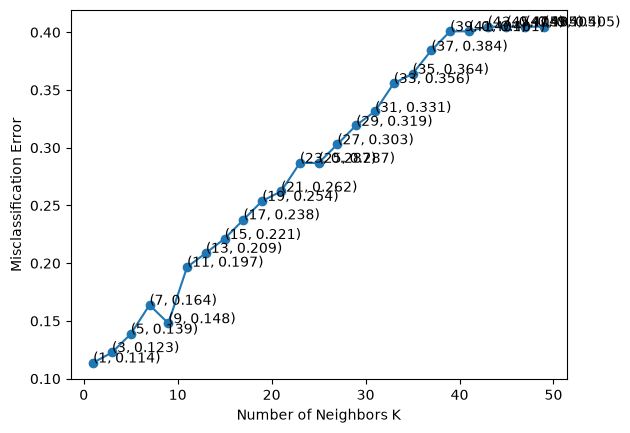

the misclassification error for each k value is :  [0.114 0.123 0.139 0.164 0.148 0.197 0.209 0.221 0.238 0.254 0.262 0.287
 0.287 0.303 0.319 0.331 0.356 0.364 0.384 0.401 0.401 0.405 0.405 0.405
 0.405]


In [17]:
# creating odd list of K for KNN
myList = list(range(0, 50))
neighbors = list(filter(lambda x: x % 2 != 0, myList))

# empty list that will hold cv scores
cv_scores = []

# perform 10-fold cross validation
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Using x_tr and y_tr from your previous split (change if using x_1/y_1)
    scores = cross_val_score(knn, x_tr, y_tr, cv=10, scoring="accuracy")
    cv_scores.append(scores.mean())

# changing to misclassification error
MSE = [1 - n for n in cv_scores]

# determining best k
optimal_k = neighbors[MSE.index(min(MSE))]
print("\nThe optimal number of neighbors is %d." % optimal_k)

# plot misclassification error vs k
plt.plot(neighbors, MSE, marker='o')

for xy in zip(neighbors, np.round(MSE, 3)):
    plt.annotate("(%s, %s)" % xy, xy=xy, xytext=xy, textcoords="data")

plt.xlabel("Number of Neighbors K")
plt.ylabel("Misclassification Error")
plt.show()

print("the misclassification error for each k value is : ", np.round(MSE, 3))

In [16]:
# ============================== KNN with k = optimal_k ===============================================
# instantiate learning model k = optimal_k
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)

# fitting the model
knn_optimal.fit(x_tr, y_tr)

# predict the response
pred = knn_optimal.predict(x_test)

# evaluate accuracy
acc = accuracy_score(y_test, pred) * 100
print('\nThe accuracy of the knn classifier for k = %d is %f%%' % (optimal_k, acc))


The accuracy of the knn classifier for k = 1 is 89.333333%


In [19]:
from sklearn.model_selection import cross_val_score
from sklearn import datasets, linear_model
from sklearn.neighbors import KNeighborsClassifier
diabetes = datasets.load_diabetes()
x = diabetes.data[:150]
y = diabetes.target[:150]
# creating odd list of K for KNN
myList = list(range(0,10))
neighbors = list(filter(lambda x: x % 2 != 0, myList))

# empty list that will hold cv scores
cv_scores = []

# perform 10-fold cross validation
for k in neighbors:
    print(k)
    knn = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(knn, x, y, cv=2, scoring='accuracy')
    print(x)
    cv_scores.append(scores.mean())


1
[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [-0.05637009 -0.04464164  0.09295276 ...  0.02545259  0.02606052
   0.04034337]
 [-0.06000263  0.05068012  0.01535029 ... -0.00259226 -0.03074792
  -0.0010777 ]
 [-0.04910502  0.05068012 -0.00512814 ...  0.07120998  0.06123763
  -0.03835666]]
3
[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [-0.05637009 -0.04464164  0.09295276 ...  0.02545259  0.02606052
   0.04034337]
 [-0.06000263  0.05068012  0.01535029 ... -0.00259226 -0.03074792
  -0.0010777 ]
 [-0.04910502  0.05068012 -0.00512814 ...  0.07120998  0.06123763
  -0.03835666]]
5
[[ 0.03807

d:\Workspace\ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
d:\Workspace\ML\.venv\Lib\site-packages\sklearn\neighbors\_base.py:501: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
d:\Workspace\ML\.venv\Lib\site-packages\sklearn\neighbors\_base.py:501: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)
d:\Workspace\ML\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=2.
  warnings.warn(
d:\Workspace\ML\.venv\Lib\site-packages\sklearn\neighbors\_base.py:501: UserWarning: T